<a href="https://colab.research.google.com/github/bhandarisiddharth142-sys/HackXPrep159/blob/main/Final_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Customer Complaint Categories in E-Commerce




In [192]:
# Basic imports
import os
import re
import zipfile
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    precision_recall_fscore_support,
    classification_report,
    hamming_loss,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)


In [193]:
DATA_DIR = "/content/olist_data"

if not os.path.exists(DATA_DIR) or len(os.listdir(DATA_DIR)) == 0:
    os.makedirs(DATA_DIR, exist_ok=True)

    zip_path = "/content/DataBase.zip"
    if not os.path.exists(zip_path):
        try:
            from google.colab import files
            print("Please upload DataBase.zip")
            uploaded = files.upload()
            zip_path = "/content/" + list(uploaded.keys())[0]
        except ImportError:
            raise FileNotFoundError(
                "DataBase.zip not found. Upload it to /content/ (or unzip the CSVs into "
                f"{DATA_DIR} yourself) and re-run this cell."
            )

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)

print("Files found:")
print(os.listdir(DATA_DIR))


Files found:
['olist_products_dataset.csv', 'olist_customers_dataset.csv', 'olist_sellers_dataset.csv', 'olist_orders_dataset.csv', 'product_category_name_translation.csv', 'olist_order_payments_dataset.csv', 'olist_geolocation_dataset.csv', 'olist_order_reviews_dataset.csv', 'olist_order_items_dataset.csv']


In [194]:
# Load all the tables
orders     = pd.read_csv(f"{DATA_DIR}/olist_orders_dataset.csv")
reviews    = pd.read_csv(f"{DATA_DIR}/olist_order_reviews_dataset.csv")
items      = pd.read_csv(f"{DATA_DIR}/olist_order_items_dataset.csv")
products   = pd.read_csv(f"{DATA_DIR}/olist_products_dataset.csv")
customers  = pd.read_csv(f"{DATA_DIR}/olist_customers_dataset.csv")
sellers    = pd.read_csv(f"{DATA_DIR}/olist_sellers_dataset.csv")
payments   = pd.read_csv(f"{DATA_DIR}/olist_order_payments_dataset.csv")
cat_trans  = pd.read_csv(f"{DATA_DIR}/product_category_name_translation.csv")

for name, df in [("orders", orders), ("reviews", reviews), ("items", items),
                  ("products", products), ("customers", customers),
                  ("sellers", sellers), ("payments", payments)]:
    print(f"{name:10s} -> {df.shape}")


orders     -> (99441, 8)
reviews    -> (99224, 7)
items      -> (112650, 7)
products   -> (32951, 9)
customers  -> (99441, 5)
sellers    -> (3095, 4)
payments   -> (103886, 5)


## Exploratory Data Analysis (EDA)



### Data quality: missing values and duplicates

In [195]:
print("Missing values per table (top columns):\n")
for name, df in [("orders", orders), ("reviews", reviews), ("items", items),
                  ("products", products), ("customers", customers),
                  ("sellers", sellers), ("payments", payments)]:
    miss = df.isna().sum()
    miss = miss[miss > 0]
    print(f"--- {name} ---")
    print(miss if len(miss) else "no missing values")
    print()


Missing values per table (top columns):

--- orders ---
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

--- reviews ---
review_comment_title      87656
review_comment_message    58247
dtype: int64

--- items ---
no missing values

--- products ---
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

--- customers ---
no missing values

--- sellers ---
no missing values

--- payments ---
no missing values



In [196]:
# Duplicate review_ids
print("Duplicate review_ids before cleaning:", reviews['review_id'].duplicated().sum())
reviews = reviews.drop_duplicates(subset='review_id').reset_index(drop=True)
print("Reviews shape after dropping duplicates:", reviews.shape)

# Order status counts (helps decide the "delivered" filter)
print("\nOrder status counts:")
print(orders['order_status'].value_counts())


Duplicate review_ids before cleaning: 814
Reviews shape after dropping duplicates: (98410, 7)

Order status counts:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [197]:
# Keep only delivered orders for clean delivery-timing features
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

# Parse dates
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date', 'order_estimated_delivery_date']
for c in date_cols:
    orders_delivered[c] = pd.to_datetime(orders_delivered[c])

print("Delivered orders:", orders_delivered.shape)


Delivered orders: (96478, 8)


### Distribution of review scores

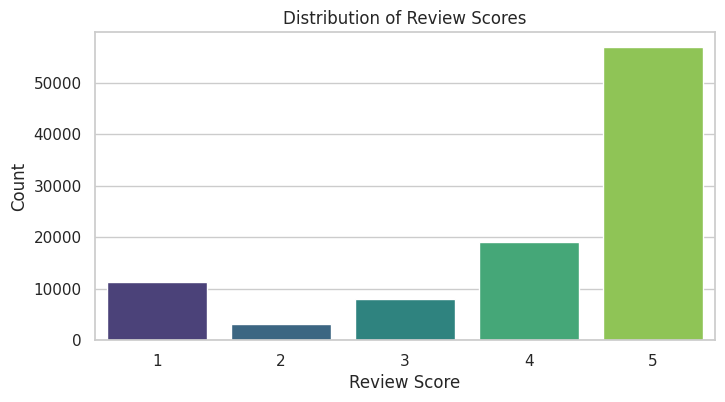

In [198]:
plt.figure()
sns.countplot(data=reviews, x='review_score', order=[1,2,3,4,5], palette='viridis')
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()


###  Delivery time and delivery delay

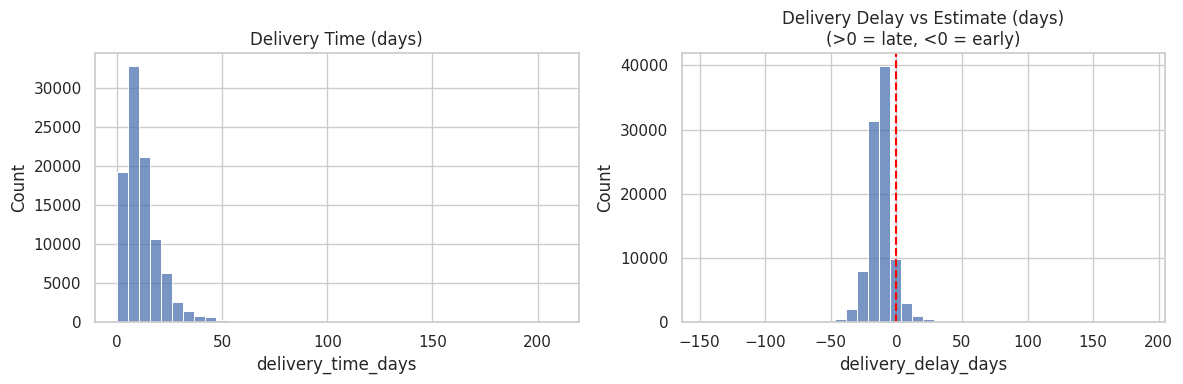

Share of delivered orders that arrived LATE: 6.8%


In [199]:
orders_delivered['delivery_time_days'] = (
    orders_delivered['order_delivered_customer_date'] - orders_delivered['order_purchase_timestamp']
).dt.days

orders_delivered['delivery_delay_days'] = (
    orders_delivered['order_delivered_customer_date'] - orders_delivered['order_estimated_delivery_date']
).dt.days
# positive delivery_delay_days = arrived AFTER the estimate (late)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(orders_delivered['delivery_time_days'].dropna(), bins=40, ax=axes[0])
axes[0].set_title("Delivery Time (days)")

sns.histplot(orders_delivered['delivery_delay_days'].dropna(), bins=40, ax=axes[1])
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title("Delivery Delay vs Estimate (days)\n(>0 = late, <0 = early)")
plt.tight_layout()
plt.show()

pct_late = (orders_delivered['delivery_delay_days'] > 0).mean()
print(f"Share of delivered orders that arrived LATE: {pct_late:.1%}")


###  Price and freight value

In [200]:
order_value = items.groupby('order_id').agg(
    price=('price', 'sum'),
    freight_value=('freight_value', 'sum'),
    n_items=('order_item_id', 'count')
).reset_index()

print(order_value[['price', 'freight_value', 'n_items']].describe())

              price  freight_value       n_items
count  98666.000000   98666.000000  98666.000000
mean     137.754076      22.823562      1.141731
std      210.645145      21.650909      0.538452
min        0.850000       0.000000      1.000000
25%       45.900000      13.850000      1.000000
50%       86.900000      17.170000      1.000000
75%      149.900000      24.040000      1.000000
max    13440.000000    1794.960000     21.000000


###  Product categories

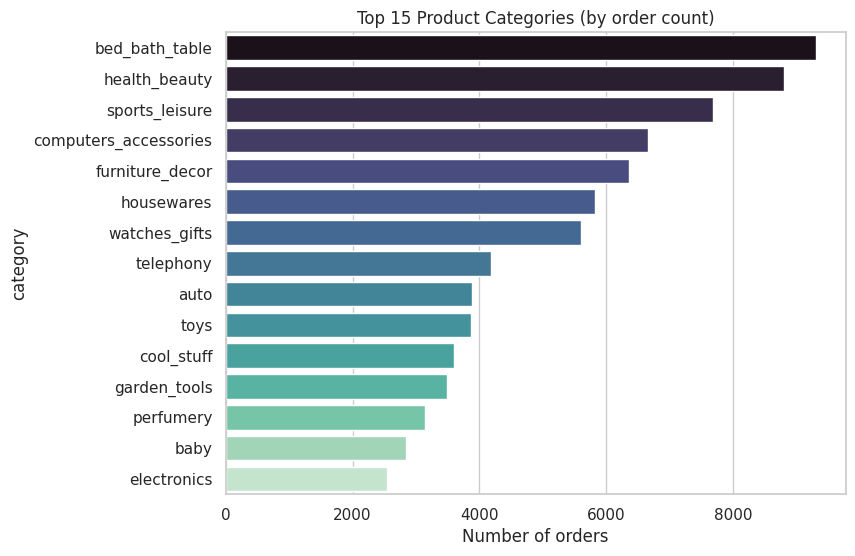

In [201]:
# One row per order for category: first item's product, then its category
first_item = items.sort_values(['order_id', 'order_item_id']).drop_duplicates('order_id', keep='first')
order_category = first_item.merge(products[['product_id', 'product_category_name']], on='product_id', how='left')
order_category = order_category.merge(cat_trans, on='product_category_name', how='left')
order_category = order_category[['order_id', 'product_category_name_english']].rename(
    columns={'product_category_name_english': 'category'}
)
order_category['category'] = order_category['category'].fillna('unknown')

top_categories = order_category['category'].value_counts().head(15)
plt.figure(figsize=(8, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='mako')
plt.title("Top 15 Product Categories (by order count)")
plt.xlabel("Number of orders")
plt.show()


### Customer and seller locations

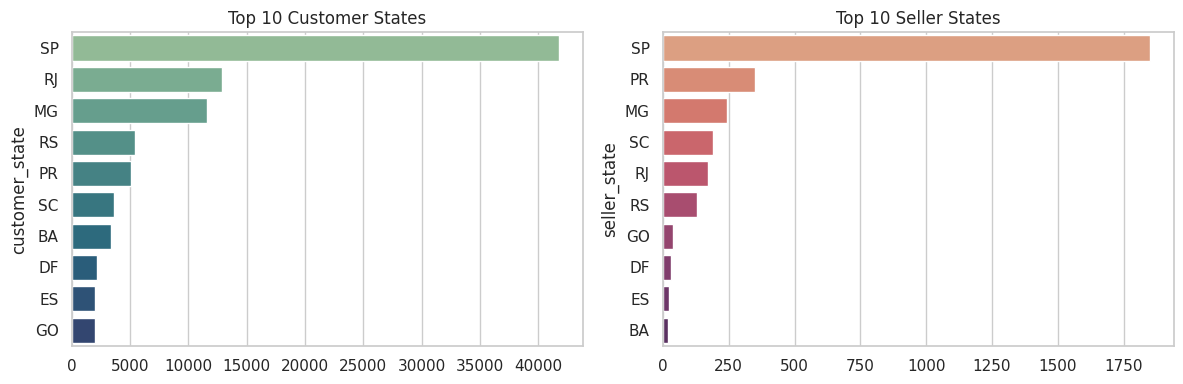

In [202]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cust_state = customers['customer_state'].value_counts().head(10)
sns.barplot(x=cust_state.values, y=cust_state.index, ax=axes[0], palette='crest')
axes[0].set_title("Top 10 Customer States")

sell_state = sellers['seller_state'].value_counts().head(10)
sns.barplot(x=sell_state.values, y=sell_state.index, ax=axes[1], palette='flare')
axes[1].set_title("Top 10 Seller States")

plt.tight_layout()
plt.show()


### Relationships with customer satisfaction


In [203]:
# Base table: one row per delivered order
sat = orders_delivered[['order_id', 'customer_id', 'delivery_time_days', 'delivery_delay_days']].copy()

# Attach the review score (an order can have >1 review; take the first review per order)
review_by_order = reviews.sort_values('review_creation_date').drop_duplicates('order_id', keep='first')
sat = sat.merge(review_by_order[['order_id', 'review_score']], on='order_id', how='inner')

# Attach price / freight / n_items
sat = sat.merge(order_value, on='order_id', how='left')

# Attach category
sat = sat.merge(order_category, on='order_id', how='left')

# Attach customer state
sat = sat.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')

# Attach seller state (first item's seller)
sat = sat.merge(first_item[['order_id', 'seller_id']], on='order_id', how='left')
sat = sat.merge(sellers[['seller_id', 'seller_state']], on='seller_id', how='left')

sat['is_late'] = sat['delivery_delay_days'] > 0

print(sat.shape)
sat.head()


(95372, 13)


,order_id,customer_id,delivery_time_days,delivery_delay_days,review_score,price,freight_value,n_items,category,customer_state,seller_id,seller_state,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,8.0,-8.0,4,29.99,8.72,1,housewares,SP,3504c0cb71d7fa48d967e0e4c94d59d9,SP,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,13.0,-6.0,4,118.70,22.76,1,perfumery,BA,289cdb325fb7e7f891c38608bf9e0962,SP,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,9.0,-18.0,5,159.90,19.22,1,auto,GO,4869f7a5dfa277a7dca6462dcf3b52b2,SP,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,13.0,-13.0,5,45.00,27.20,1,pet_shop,RN,66922902710d126a0e7d26b0e3805106,MG,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2.0,-10.0,5,19.90,8.72,1,stationery,SP,2c9e548be18521d1c43cde1c582c6de8,SP,False


**1) Delivery delay → satisfaction**

Average review score, on-time vs late:
is_late
False    4.292768
True     2.271982
Name: review_score, dtype: float64


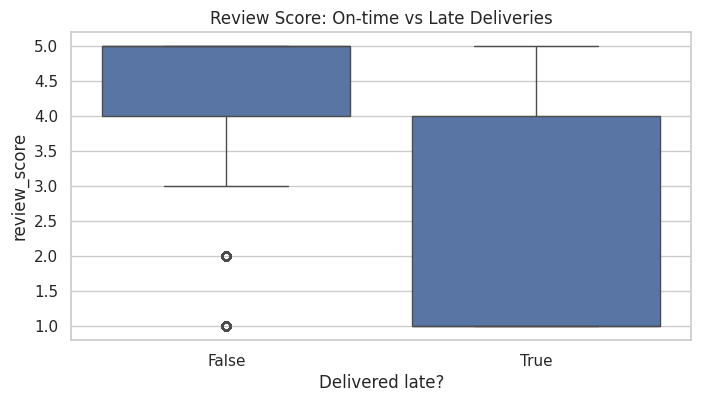

Correlation(delivery_delay_days, review_score) = -0.267


In [204]:
late_vs_score = sat.groupby('is_late')['review_score'].mean()
print("Average review score, on-time vs late:")
print(late_vs_score)

plt.figure()
sns.boxplot(data=sat, x='is_late', y='review_score')
plt.title("Review Score: On-time vs Late Deliveries")
plt.xlabel("Delivered late?")
plt.show()

corr_delay = sat[['delivery_delay_days', 'review_score']].corr().iloc[0, 1]
print(f"Correlation(delivery_delay_days, review_score) = {corr_delay:.3f}")


**2) Product category → satisfaction**

5 lowest-rated categories (min 50 orders):
                           mean  count
category                              
office_furniture       3.650936   1229
fashion_male_clothing  3.817308    104
audio                  3.847507    341
home_confort           3.920981    367
fixed_telephony        3.966507    209

5 highest-rated categories (min 50 orders):
                                           mean  count
category                                              
books_technical                        4.422925    253
costruction_tools_tools                4.425532     94
small_appliances_home_oven_and_coffee  4.430556     72
food_drink                             4.446512    215
books_general_interest                 4.539877    489


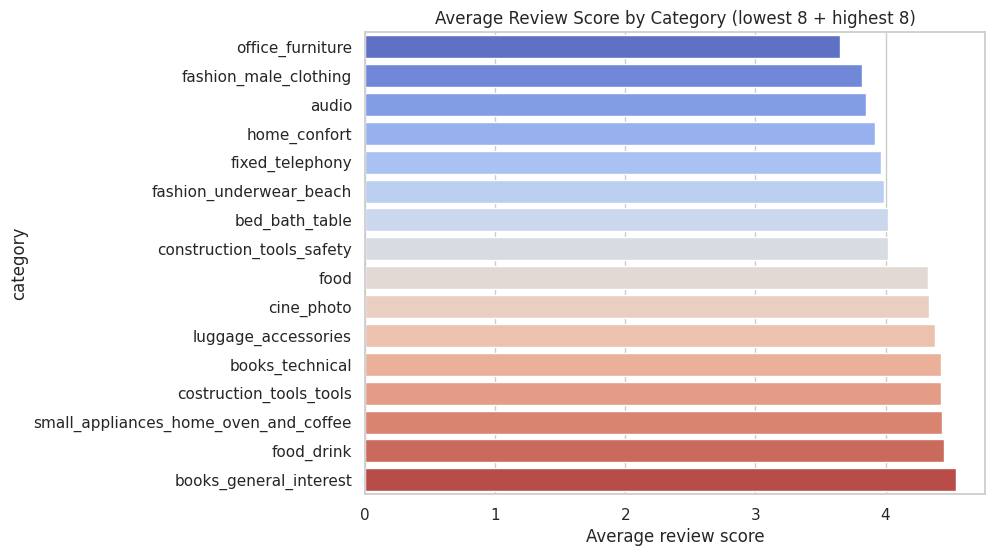

In [205]:
cat_score = sat.groupby('category')['review_score'].agg(['mean', 'count'])
cat_score = cat_score[cat_score['count'] >= 50].sort_values('mean')

print("5 lowest-rated categories (min 50 orders):")
print(cat_score.head())
print("\n5 highest-rated categories (min 50 orders):")
print(cat_score.tail())

plt.figure(figsize=(8, 6))
combo = pd.concat([cat_score.head(8), cat_score.tail(8)])
sns.barplot(x=combo['mean'], y=combo.index, palette='coolwarm')
plt.title("Average Review Score by Category (lowest 8 + highest 8)")
plt.xlabel("Average review score")
plt.show()


**3) Freight cost → satisfaction (controlling for delivery delay)**

In [206]:
for late_flag, label in [(False, "On-time orders"), (True, "Late orders")]:
    subset = sat[sat['is_late'] == late_flag]
    corr = subset[['freight_value', 'review_score']].corr().iloc[0, 1]
    print(f"{label:15s}: correlation(freight_value, review_score) = {corr:.3f}  (n={len(subset)})")


On-time orders : correlation(freight_value, review_score) = -0.091  (n=89026)
Late orders    : correlation(freight_value, review_score) = -0.028  (n=6346)


**4) Location → satisfaction (controlling for delivery delay)**


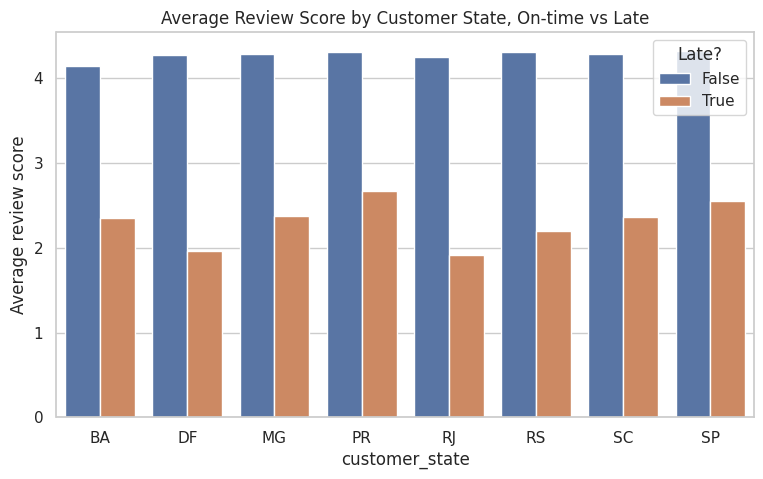

In [207]:
loc_score = sat.groupby(['customer_state', 'is_late'])['review_score'].agg(['mean', 'count']).reset_index()
loc_score = loc_score[loc_score['count'] >= 30]

top_states = sat['customer_state'].value_counts().head(8).index
loc_score_top = loc_score[loc_score['customer_state'].isin(top_states)]

plt.figure(figsize=(9, 5))
sns.barplot(data=loc_score_top, x='customer_state', y='mean', hue='is_late')
plt.title("Average Review Score by Customer State, On-time vs Late")
plt.ylabel("Average review score")
plt.legend(title="Late?")
plt.show()


### EDA takeaway

- **Delivery delay** shows a clear, consistent relationship with satisfaction — late orders get noticeably lower scores.
- **Product category** shows some spread in average scores, worth keeping as a feature.
- Once we split by on-time vs late, **freight cost** and **location** differences shrink — most of their apparent effect
  on satisfaction was really riding on delivery delay. We still keep them as features (they may add a little on their own),
  but delivery delay is the strongest, most consistent signal for the ML model.


##  NLP-Based Complaint Labeling


### Text dataset

In [208]:
text_df = reviews.dropna(subset=['review_comment_message']).copy()
text_df = text_df.drop_duplicates(subset='review_id').reset_index(drop=True)
print("Reviews with text:", text_df.shape)
text_df[['review_id', 'order_id', 'review_comment_message']].head()


Reviews with text: (40668, 7)


,review_id,order_id,review_comment_message
0,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,Recebi bem antes do prazo estipulado.
1,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,Parabéns lojas lannister adorei comprar pela I...
2,8670d52e15e00043ae7de4c01cc2fe06,b9bf720beb4ab3728760088589c62129,aparelho eficiente. no site a marca do aparelh...
3,4b49719c8a200003f700d3d986ea1a19,9d6f15f95d01e79bd1349cc208361f09,"Mas um pouco ,travando...pelo valor ta Boa.\r\n"
4,3948b09f7c818e2d86c9a546758b2335,e51478e7e277a83743b6f9991dbfa3fb,"Vendedor confiável, produto ok e entrega antes..."


### Cleaning the text

In [209]:
# A small, simple stopword list for Portuguese (no external downloads needed)
pt_stopwords_text = (
    "a o e e de da do das dos em um uma uns umas para por com sem que se na no nas nos "
    "ao aos a as como mais muito pouco ja foi ser esta estou esta este esse essa isso isto "
    "mas ou nao sim eu tu ele ela nos vos eles elas meu minha teu tua seu sua nosso nossa "
    "me te lhe pra pro"
)
PT_STOPWORDS = set(pt_stopwords_text.split())

def clean_text(text):
    text = str(text).lower()
    # strip accents
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    # keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [t for t in text.split() if t not in PT_STOPWORDS and len(t) > 1]
    return ' '.join(tokens)

text_df['clean_text'] = text_df['review_comment_message'].apply(clean_text)
text_df[['review_comment_message', 'clean_text']].head()


,review_comment_message,clean_text
0,Recebi bem antes do prazo estipulado.,recebi bem antes prazo estipulado
1,Parabéns lojas lannister adorei comprar pela I...,parabens lojas lannister adorei comprar pela i...
2,aparelho eficiente. no site a marca do aparelh...,aparelho eficiente site marca aparelho impress...
3,"Mas um pouco ,travando...pelo valor ta Boa.\r\n",travando pelo valor ta boa
4,"Vendedor confiável, produto ok e entrega antes...",vendedor confiavel produto ok entrega antes prazo


### Keyword-based labeling functions

In [210]:

KEYWORDS = {
    'Delivery': ['atras', 'atraso', 'atrasad', 'demorou', 'demora', 'demorando', 'entrega', 'entreg', 'entregador', 'nao receb', 'não receb', 'nao chegou', 'não chegou', 'ainda nao chegou', 'ainda não chegou', 'aguardando entrega', 'esperando entrega', 'prazo de entrega', 'fora do prazo', 'entrega atrasada', 'pedido atrasado', 'pedido nao chegou', 'pedido não chegou', 'objeto nao chegou', 'objeto não chegou', 'encomenda nao chegou', 'encomenda não chegou', 'rastreamento', 'rastreio', 'transportadora'],

    'Product': ['diferente', 'nao confere', 'não confere', 'defeito', 'defeituoso', 'defeituosa', 'quebrad', 'quebrou', 'nao funciona', 'não funciona', 'funciona mal', 'com problema', 'problema no produto', 'produto errado', 'produto diferente', 'item errado', 'modelo errado', 'tamanho errado', 'cor errada', 'cor diferente', 'faltando peça', 'peca faltando', 'peça faltando', 'incompleto', 'incompleta', 'danificado', 'danificada', 'nao liga', 'não liga', 'nao carrega', 'não carrega', 'parou de funcionar', 'nao presta', 'não presta', 'baixa qualidade', 'qualidade ruim', 'usado', 'falso', 'falsificado', 'produto incorreto'],

    'Packaging': ['danificad', 'danificada', 'danificado', 'quebrado na caixa', 'quebrada na caixa', 'embalagem', 'pacote', 'caixa', 'caixa danificada', 'caixa quebrada', 'pacote danificado', 'pacote quebrado', 'embalagem danificada', 'embalagem quebrada', 'embalagem rasgada', 'caixa rasgada', 'pacote rasgado', 'amassado', 'amassada', 'caixa amassada', 'pacote amassado', 'lacrado', 'lacre', 'sem lacre', 'aberto', 'embalagem aberta', 'pacote aberto', 'proteção insuficiente', 'mal embalado', 'mal embalada'],

    'Seller': ['vendedor', 'vendedora', 'atendimento', 'atendente', 'nao respond', 'não respond', 'nao responde', 'não responde', 'nao respondeu', 'não respondeu', 'sem resposta', 'nao responde mensagem', 'não responde mensagem', 'nao entrou em contato', 'não entrou em contato', 'contato com vendedor', 'falar com vendedor', 'suporte', 'atendimento ruim', 'mau atendimento', 'péssimo atendimento', 'pessimo atendimento', 'vendedor ruim', 'vendedor nao ajudou', 'vendedor não ajudou', 'vendedor nao responde', 'vendedor não responde', 'nao me respondeu', 'não me respondeu', 'ignorou minha mensagem', 'sem suporte'],

    'Payment': ['cobranca', 'cobrança', 'cobrado', 'cobrada', 'cobrou', 'pagamento', 'pagar', 'pagamento duplicado', 'cobrado duas vezes', 'cobrado a mais', 'valor errado', 'preço errado', 'preco errado', 'preço diferente', 'preco diferente', 'valor diferente', 'frete', 'frete caro', 'taxa', 'taxa extra', 'tarifa', 'reembolso', 'reembolsar', 'estorno', 'estornar', 'dinheiro de volta', 'devolução do dinheiro', 'devolucao do dinheiro', 'pagamento recusado', 'pagamento negado', 'cartão', 'cartao', 'pix', 'boleto', 'parcelamento', 'parcela', 'juros']
}

CATEGORIES = list(KEYWORDS.keys())
NEGATIVE_SCORE_THRESHOLD = 3

def label_review(row):
    labels = {}
    is_negative = row['review_score'] <= NEGATIVE_SCORE_THRESHOLD
    for cat, keywords in KEYWORDS.items():
        keyword_hit = any(kw in row['clean_text'] for kw in keywords)
        labels[cat] = int(keyword_hit and is_negative)
    return pd.Series(labels)

label_matrix = text_df.apply(label_review, axis=1)
text_df = pd.concat([text_df, label_matrix], axis=1)

print("Label counts (a review can have more than one label, or none at all):")
print(text_df[CATEGORIES].sum())
print(f"\nReviews with NO complaint category detected: {(text_df[CATEGORIES].sum(axis=1) == 0).sum()} / {len(text_df)}")

print("\nExample multi-label reviews:")
multi = text_df[text_df[CATEGORIES].sum(axis=1) > 1]
multi[['review_comment_message', 'review_score'] + CATEGORIES].head(5)


Label counts (a review can have more than one label, or none at all):
Delivery     4314
Product      1399
Packaging     718
Seller        385
Payment       794
dtype: int64

Reviews with NO complaint category detected: 34098 / 40668

Example multi-label reviews:


,review_comment_message,review_score,Delivery,Product,Packaging,Seller,Payment
98,"Demora na entrega, detestei o atendimento e NU...",1,1,0,0,1,0
108,"Apesar de ter sido entregue rapidamente, subst...",3,1,0,1,0,0
119,Cancelaram a minha compra um dia antes da entr...,1,1,0,0,1,1
146,"A embalagem deixou a desejar, por pouco o prod...",3,0,1,1,0,0
178,A targaryen não é de confiança não entregou a ...,1,1,0,0,0,1


### TF-IDF + Logistic Regression

In [211]:
X_text = text_df['clean_text']
Y_text = text_df[CATEGORIES]

X_train_txt, X_test_txt, y_train_txt, y_test_txt = train_test_split(
    X_text, Y_text, test_size=0.2, random_state=42
)

tfidf = TfidfVectorizer(max_features=3000, min_df=3)
X_train_tfidf = tfidf.fit_transform(X_train_txt)
X_test_tfidf = tfidf.transform(X_test_txt)

text_clf = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced'))
text_clf.fit(X_train_tfidf, y_train_txt)

y_pred_txt = text_clf.predict(X_test_tfidf)


### Evaluating the text classifier

In [212]:
print(classification_report(y_test_txt, y_pred_txt, target_names=CATEGORIES, zero_division=0))
print(f"Hamming Loss: {hamming_loss(y_test_txt, y_pred_txt):.3f}")


              precision    recall  f1-score   support

    Delivery       0.57      0.90      0.70       847
     Product       0.67      0.96      0.79       289
   Packaging       0.64      0.94      0.76       145
      Seller       0.34      0.86      0.48        77
     Payment       0.64      0.96      0.77       168

   micro avg       0.58      0.92      0.71      1526
   macro avg       0.57      0.92      0.70      1526
weighted avg       0.59      0.92      0.72      1526
 samples avg       0.14      0.15      0.14      1526

Hamming Loss: 0.028


## Main ML Model


###  Order-level feature table

In [213]:
# Payment info aggregated to one row per order
payment_agg = payments.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    n_installments=('payment_installments', 'max'),
).reset_index()

most_common_payment = (
    payments.sort_values('payment_value', ascending=False)
    .drop_duplicates('order_id', keep='first')[['order_id', 'payment_type']]
)
payment_agg = payment_agg.merge(most_common_payment, on='order_id', how='left')

# Start from the delivered-orders satisfaction table built in the EDA step (has delay, price,
# freight, n_items, category, customer_state, seller_state, review_score)
model_df = sat.merge(payment_agg, on='order_id', how='left')

print(model_df.shape)
model_df.head()


(95372, 16)


,order_id,customer_id,delivery_time_days,delivery_delay_days,review_score,price,freight_value,n_items,category,customer_state,seller_id,seller_state,is_late,total_payment_value,n_installments,payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,8.0,-8.0,4,29.99,8.72,1,housewares,SP,3504c0cb71d7fa48d967e0e4c94d59d9,SP,False,38.71,1.0,voucher
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,13.0,-6.0,4,118.70,22.76,1,perfumery,BA,289cdb325fb7e7f891c38608bf9e0962,SP,False,141.46,1.0,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,9.0,-18.0,5,159.90,19.22,1,auto,GO,4869f7a5dfa277a7dca6462dcf3b52b2,SP,False,179.12,3.0,credit_card
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,13.0,-13.0,5,45.00,27.20,1,pet_shop,RN,66922902710d126a0e7d26b0e3805106,MG,False,72.20,1.0,credit_card
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2.0,-10.0,5,19.90,8.72,1,stationery,SP,2c9e548be18521d1c43cde1c582c6de8,SP,False,28.62,1.0,credit_card


###  Attaching them together

In [214]:
labels_df = text_df[['order_id'] + CATEGORIES].drop_duplicates(subset='order_id')

model_df = model_df.merge(labels_df, on='order_id', how='inner')  # inner join: only orders with text labels
print("Orders with both features and complaint labels:", model_df.shape)
model_df[CATEGORIES].sum()


Orders with both features and complaint labels: (38758, 21)


,0
Delivery,3660
Product,1360
Packaging,703
Seller,316
Payment,592


### Train / test split and train both models

In [215]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

log_reg = OneVsRestClassifier(LogisticRegression(max_iter=1000, class_weight='balanced'))
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

rf = OneVsRestClassifier(RandomForestClassifier(n_estimators=300, max_depth=10, class_weight='balanced', random_state=42))
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Both models trained.")


Both models trained.


### Example

In [216]:
example_idx = 0
example_order = X_test.iloc[[example_idx]]

# Use Random Forest's predicted probabilities for the example
proba_per_label = [est.predict_proba(example_order)[:, 1][0] for est in rf.estimators_]

example_output = pd.DataFrame({
    'Complaint Category': CATEGORIES,
    'Probability': [f'{p:.0%}' for p in proba_per_label]
}).sort_values('Probability', ascending=False)

print("Predicted complaint probabilities for one unseen order:\n")
print(example_output.to_string(index=False))


Predicted complaint probabilities for one unseen order:

Complaint Category Probability
           Product         49%
            Seller         33%
           Payment         32%
          Delivery         30%
         Packaging         20%


## Model Evaluation

### Logistic Regression vs Random Forest

In [217]:
print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr, target_names=CATEGORIES, zero_division=0))
print(f"Hamming Loss: {hamming_loss(y_test, y_pred_lr):.3f}")

print("\n=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=CATEGORIES, zero_division=0))
print(f"Hamming Loss: {hamming_loss(y_test, y_pred_rf):.3f}")


=== Logistic Regression ===
              precision    recall  f1-score   support

    Delivery       0.23      0.62      0.34       725
     Product       0.04      0.53      0.08       273
   Packaging       0.03      0.54      0.05       148
      Seller       0.02      0.59      0.03        66
     Payment       0.03      0.52      0.06       129

   micro avg       0.06      0.58      0.11      1341
   macro avg       0.07      0.56      0.11      1341
weighted avg       0.14      0.58      0.21      1341
 samples avg       0.04      0.09      0.05      1341

Hamming Loss: 0.328

=== Random Forest ===
              precision    recall  f1-score   support

    Delivery       0.25      0.57      0.35       725
     Product       0.05      0.21      0.08       273
   Packaging       0.04      0.20      0.07       148
      Seller       0.02      0.09      0.04        66
     Payment       0.05      0.19      0.08       129

   micro avg       0.12      0.39      0.19      1341
   mac

### Feature importance

In [218]:
# Logistic Regression coefficients, per label (positive = higher chance of that complaint)
for i, cat in enumerate(CATEGORIES):
    coefs = pd.Series(log_reg.estimators_[i].coef_[0], index=X.columns)
    top_pos = coefs.sort_values(ascending=False).head(5)
    print(f"--- {cat}: features that INCREASE predicted complaint probability ---")
    print(top_pos.round(3))
    print()


--- Delivery: features that INCREASE predicted complaint probability ---
n_items               0.692
customer_state_SP     0.157
customer_state_RJ     0.154
customer_state_MG     0.075
delivery_time_days    0.068
dtype: float64

--- Product: features that INCREASE predicted complaint probability ---
seller_state_DF                   0.799
category_telephony                0.420
category_computers_accessories    0.316
category_watches_gifts            0.278
seller_state_other                0.258
dtype: float64

--- Packaging: features that INCREASE predicted complaint probability ---
seller_state_DF           0.789
customer_state_DF         0.597
category_watches_gifts    0.462
seller_state_other        0.434
n_items                   0.414
dtype: float64

--- Seller: features that INCREASE predicted complaint probability ---
n_items                    0.825
seller_state_BA            0.712
customer_state_DF          0.448
seller_state_DF            0.423
payment_type_debit_card    0.3

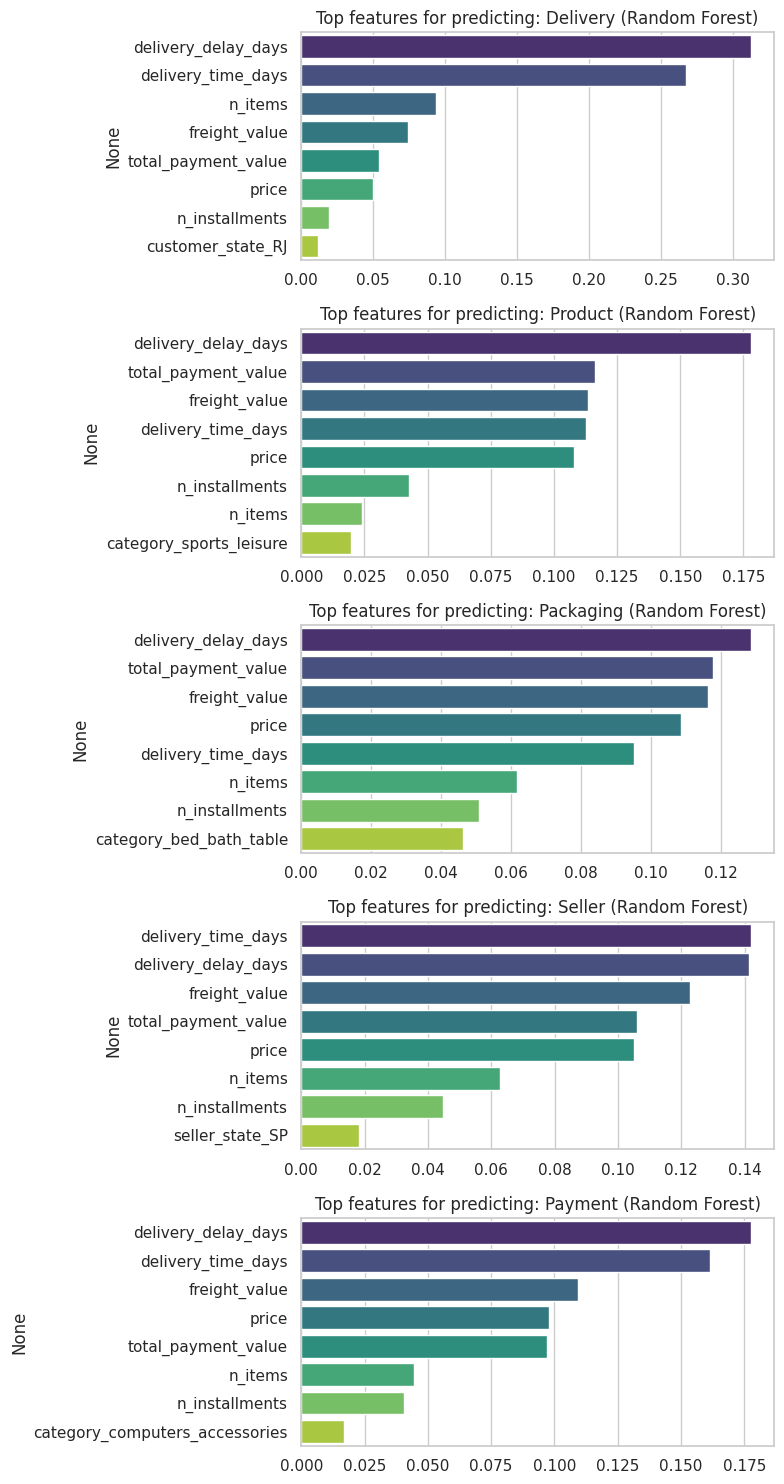

In [219]:
# Random Forest feature importance, per label
fig, axes = plt.subplots(len(CATEGORIES), 1, figsize=(8, 3 * len(CATEGORIES)))
for i, cat in enumerate(CATEGORIES):
    importances = pd.Series(rf.estimators_[i].feature_importances_, index=X.columns)
    top_feats = importances.sort_values(ascending=False).head(8)
    sns.barplot(x=top_feats.values, y=top_feats.index, ax=axes[i], palette='viridis')
    axes[i].set_title(f"Top features for predicting: {cat} (Random Forest)")
plt.tight_layout()
plt.show()
